# 🍵 Tea Garden Climate Risk Analyzer
## EDA & Feature Engineering
This notebook covers:
- Raw data ingestion and column normalization
- Outlier capping
- Date/time and season feature engineering
- Rolling aggregates and deviation features
- Climate Stress Index (CSI) construction
- Label generation (stress_level)
- EDA visualizations

## 1. Imports & Settings

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

# Consistent plot style
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13})

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "Data").exists() or not (PROJECT_ROOT / "Figures").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "Data" / "Indian_Climate_Dataset_2024_2025.csv"
FIGURES_DIR = PROJECT_ROOT / "Figures"
DATA_OUTPUT_DIR = PROJECT_ROOT / "data"

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(DATA_OUTPUT_DIR, exist_ok=True)

print("Setup complete ✔")

Setup complete ✔


## 2. Load Dataset

In [20]:
DATA_PATH = PROJECT_ROOT / "Data" / "Indian_Climate_Dataset_2024_2025.csv"
df = pd.read_csv(DATA_PATH)

df.to_csv(DATA_OUTPUT_DIR / "raw_backup.csv", index=False)
print(f"Shape: {df.shape}")
df.head(3)

Shape: (7310, 13)


,Date,City,State,Temperature_Max (°C),Temperature_Min (°C),Temperature_Avg (°C),Humidity (%),Rainfall (mm),Wind_Speed (km/h),AQI,AQI_Category,Pressure (hPa),Cloud_Cover (%)
0,2024-01-01,Mumbai,Maharashtra,32.5,18.0,25.2,77.6,0.0,3.3,259,Poor,1020.3,62.1
1,2024-01-01,Delhi,Delhi,25.4,10.7,18.1,84.1,0.0,9.0,130,Moderate,1008.4,46.0
2,2024-01-01,Bengaluru,Karnataka,37.2,30.8,34.0,49.0,3.7,6.6,54,Satisfactory,1008.0,61.3


## 3. Column Cleaning & Renaming

In [21]:
# Normalize column names
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(r"[\s/]+", "_", regex=True)
      .str.replace(r"[^a-z0-9_]", "", regex=True)
)
print("Raw columns:", list(df.columns))

Raw columns: ['date', 'city', 'state', 'temperature_max_c', 'temperature_min_c', 'temperature_avg_c', 'humidity_', 'rainfall_mm', 'wind_speed_km_h', 'aqi', 'aqi_category', 'pressure_hpa', 'cloud_cover_']


In [22]:
# Flexible rename: match by keyword
rename_map = {}
for c in df.columns:
    if   "temp" in c:    rename_map[c] = "avg_temperature"
    elif "rain" in c:    rename_map[c] = "rainfall"
    elif "humid" in c:   rename_map[c] = "humidity"
    elif "wind" in c:    rename_map[c] = "wind_speed"
    elif "cloud" in c:   rename_map[c] = "cloud_cover"
    elif "aqi" in c:     rename_map[c] = "aqi"
    elif "date" in c:    rename_map[c] = "date"
    elif "state" in c:   rename_map[c] = "state"
    elif "city" in c:    rename_map[c] = "city"

df = df.rename(columns=rename_map)
print("Renamed columns:", [c for c in df.columns if c in rename_map.values()])

Renamed columns: ['date', 'city', 'state', 'avg_temperature', 'avg_temperature', 'avg_temperature', 'humidity', 'rainfall', 'wind_speed', 'aqi', 'aqi', 'cloud_cover']


## 4. Numeric Coercion

In [23]:
NUM_COLS = ["avg_temperature", "rainfall", "humidity",
            "wind_speed", "cloud_cover", "aqi"]

# Create a new DataFrame with unique columns, keeping the first occurrence
# for columns that were duplicated during renaming. This resolves the TypeError.
df_processed = df.loc[:, ~df.columns.duplicated(keep='first')].copy()

for c in NUM_COLS:
    if c in df_processed.columns:
        df_processed[c] = pd.to_numeric(df_processed[c], errors="coerce")

# Replace the original df with the processed one, ensuring unique columns
df = df_processed.copy()

# Clean string columns
for c in ["state", "city"]:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip().str.title()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7310 entries, 0 to 7309
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             7310 non-null   object 
 1   city             7310 non-null   object 
 2   state            7310 non-null   object 
 3   avg_temperature  7310 non-null   float64
 4   humidity         7310 non-null   float64
 5   rainfall         7310 non-null   float64
 6   wind_speed       7310 non-null   float64
 7   aqi              7310 non-null   int64  
 8   pressure_hpa     7310 non-null   float64
 9   cloud_cover      7310 non-null   float64
dtypes: float64(6), int64(1), object(3)
memory usage: 571.2+ KB


## 5. Missing Value Analysis

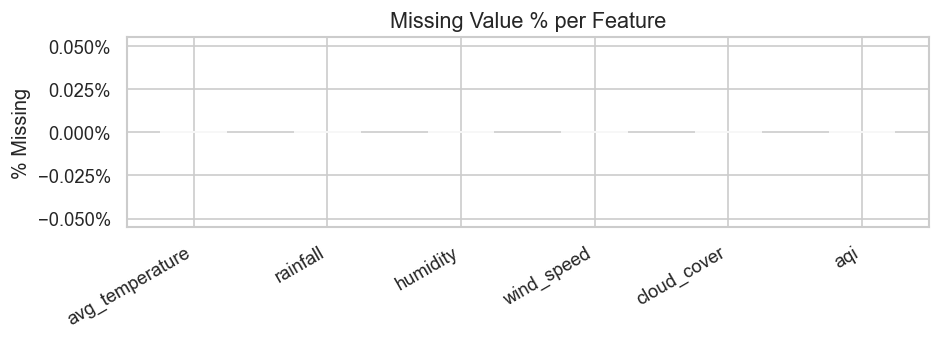

avg_temperature    0.0
rainfall           0.0
humidity           0.0
wind_speed         0.0
cloud_cover        0.0
aqi                0.0
dtype: float64


In [25]:
miss = df[NUM_COLS].isna().mean() * 100

fig, ax = plt.subplots(figsize=(8, 3))
miss.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Missing Value % per Feature")
ax.set_ylabel("% Missing")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/01_missing_values.png")
plt.show()
print(miss)

In [26]:
# Median imputation per city (falls back to global median)
for c in NUM_COLS:
    if c in df.columns:
        if "city" in df.columns:
            df[c] = df.groupby("city")[c].transform(
                lambda s: s.fillna(s.median())
            )
        df[c] = df[c].fillna(df[c].median())

print("Missing after imputation:", df[NUM_COLS].isna().sum().sum())

Missing after imputation: 0


## 6. Deduplication & Outlier Capping

In [27]:
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows")

Removed 0 duplicate rows


In [28]:
def cap_iqr(s: pd.Series) -> pd.Series:
    """Winsorise a series to [Q1 - 1.5*IQR, Q3 + 1.5*IQR]."""
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return s.clip(q1 - 1.5 * iqr, q3 + 1.5 * iqr)

for c in NUM_COLS:
    if c in df.columns:
        df[c] = cap_iqr(df[c])

print("Outlier capping done ✔")

Outlier capping done ✔


## 7. Date & Season Features

In [29]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date"])
df = df.sort_values("date").reset_index(drop=True)

df["year"]  = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"]   = df["date"].dt.day
df["week"]  = df["date"].dt.isocalendar().week.astype(int)
df["day_of_year"] = df["date"].dt.dayofyear

# Cyclical encoding so models understand month 12 ≈ month 1
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

season_map = {
    12:"Winter", 1:"Winter",  2:"Winter",
    3:"Summer",  4:"Summer",  5:"Summer",
    6:"Monsoon", 7:"Monsoon", 8:"Monsoon",
    9:"Post-Monsoon", 10:"Post-Monsoon", 11:"Post-Monsoon"
}
df["season"] = df["month"].map(season_map)

df[["date", "year", "month", "week", "season"]].head()

,date,year,month,week,season
0,2024-01-01,2024,1,1,Winter
1,2024-01-01,2024,1,1,Winter
2,2024-01-01,2024,1,1,Winter
3,2024-01-01,2024,1,1,Winter
4,2024-01-01,2024,1,1,Winter


## 8. Rolling Aggregates & Deviation Features

In [30]:
# Sort by city + date before rolling so windows don't bleed across cities
if "city" in df.columns:
    df = df.sort_values(["city", "date"]).reset_index(drop=True)
    group_key = "city"
else:
    group_key = None

ROLL_WINDOW = 7  # 7-day rolling window

for col in ["avg_temperature", "rainfall", "humidity"]:
    if col not in df.columns:
        continue

    if group_key:
        roll = df.groupby(group_key)[col].transform(
            lambda s: s.rolling(ROLL_WINDOW, min_periods=1).mean()
        )
    else:
        roll = df[col].rolling(ROLL_WINDOW, min_periods=1).mean()

    df[f"{col}_roll7"] = roll
    df[f"{col}_dev"]   = df[col] - roll   # deviation from rolling mean

print("Rolling features added:",
      [c for c in df.columns if "roll" in c or "_dev" in c])

Rolling features added: ['avg_temperature_roll7', 'avg_temperature_dev', 'rainfall_roll7', 'rainfall_dev', 'humidity_roll7', 'humidity_dev']


## 9. Climate Stress Index (CSI) & Label Creation

In [31]:
def compute_csi(row: pd.Series) -> int:
    """
    Climate Stress Index — domain-rule scoring for tea cultivation.
    Returns an integer score; higher = more stress.
    """
    score = 0

    # --- Temperature stress ---
    t = row.get("avg_temperature", 25)
    if t > 35:          score += 3
    elif t > 30:        score += 2
    elif t < 10:        score += 3   # cold stress
    elif t < 15:        score += 1

    # --- Humidity stress ---
    h = row.get("humidity", 70)
    if h < 30 or h > 90:   score += 2
    elif h < 50 or h > 85: score += 1

    # --- Rainfall stress ---
    r = row.get("rainfall", 50)
    if r == 0:          score += 3   # drought
    elif r > 200:       score += 3   # flooding risk
    elif r > 100:       score += 1

    # --- Air quality ---
    aqi = row.get("aqi", 100)
    if aqi > 300:       score += 2
    elif aqi > 200:     score += 1

    # --- Wind stress ---
    w = row.get("wind_speed", 5)
    if w > 30:          score += 2
    elif w > 20:        score += 1

    # --- Cloud cover (low = drought signal) ---
    cc = row.get("cloud_cover", 50)
    if cc < 15:         score += 1

    return score


def csi_to_stress(score: int) -> str:
    if score <= 2:  return "Healthy"
    if score <= 5:  return "Mild Stress"
    return "Severe Stress"


def csi_to_risk(score: int) -> str:
    if score <= 1:  return "Low"
    if score <= 3:  return "Moderate"
    if score <= 6:  return "High"
    return "Extreme"


df["csi"]          = df.apply(compute_csi, axis=1)
df["stress_level"] = df["csi"].apply(csi_to_stress)
df["risk_level"]   = df["csi"].apply(csi_to_risk)

print(df["stress_level"].value_counts())
print(df["risk_level"].value_counts())

stress_level
Severe Stress    3508
Mild Stress      3027
Healthy           775
Name: count, dtype: int64
risk_level
High        3376
Extreme     2279
Moderate    1250
Low          405
Name: count, dtype: int64


## 10. Select Final Columns & Save

In [32]:
base_cols = [
    "date", "state", "city",
    "avg_temperature", "rainfall", "humidity",
    "wind_speed", "cloud_cover", "aqi",
    "year", "month", "week", "day_of_year",
    "month_sin", "month_cos", "season",
    "avg_temperature_roll7", "rainfall_roll7", "humidity_roll7",
    "avg_temperature_dev",   "rainfall_dev",   "humidity_dev",
    "csi", "stress_level", "risk_level"
]

final_cols = [c for c in base_cols if c in df.columns]
df = df[final_cols]

FINAL_PATH = DATA_OUTPUT_DIR / "climate_clean_labeled.csv"
df.to_csv(FINAL_PATH, index=False)
print(f"Saved → {FINAL_PATH}  |  shape: {df.shape}")
df.head(3)

Saved → C:\Users\nilad\CSS_hackathon-Tea-Climate-Analyzer\data\climate_clean_labeled.csv  |  shape: (7310, 25)


,date,state,city,avg_temperature,rainfall,humidity,wind_speed,cloud_cover,aqi,year,month,week,day_of_year,month_sin,month_cos,season,avg_temperature_roll7,rainfall_roll7,humidity_roll7,avg_temperature_dev,rainfall_dev,humidity_dev,csi,stress_level,risk_level
0,2024-01-01,Gujarat,Ahmedabad,32.8,0.0,83.9,5.2,12.1,345,2024,1,1,1,0.5,0.866025,Winter,32.800000,0.000000,83.900000,0.000000,0.000000,0.000000,8,Severe Stress,Extreme
1,2024-01-02,Gujarat,Ahmedabad,32.4,5.4,71.2,9.4,8.9,223,2024,1,1,2,0.5,0.866025,Winter,32.600000,2.700000,77.550000,-0.200000,2.700000,-6.350000,4,Mild Stress,High
2,2024-01-03,Gujarat,Ahmedabad,37.3,5.2,39.1,18.0,39.2,131,2024,1,1,3,0.5,0.866025,Winter,34.166667,3.533333,64.733333,3.133333,1.666667,-25.633333,4,Mild Stress,High


---
## 11. EDA Visualizations

### 11.1 Stress & Risk Level Distributions

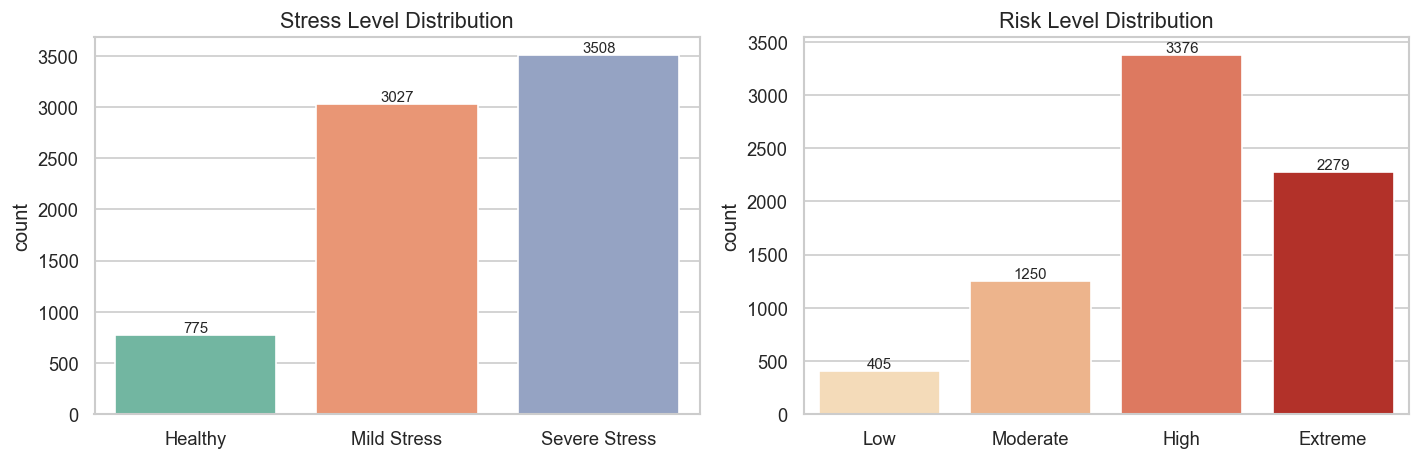

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

order_stress = ["Healthy", "Mild Stress", "Severe Stress"]
order_risk   = ["Low", "Moderate", "High", "Extreme"]

sns.countplot(data=df, x="stress_level", order=order_stress,
              palette="Set2", ax=axes[0])
axes[0].set_title("Stress Level Distribution")
axes[0].set_xlabel("")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}",
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha="center", va="bottom", fontsize=9)

sns.countplot(data=df, x="risk_level", order=order_risk,
              palette="OrRd", ax=axes[1])
axes[1].set_title("Risk Level Distribution")
axes[1].set_xlabel("")
for p in axes[1].patches:
    axes[1].annotate(f"{int(p.get_height())}",
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/02_label_distributions.png")
plt.show()

### 11.2 Feature vs Stress Level (Boxplots)

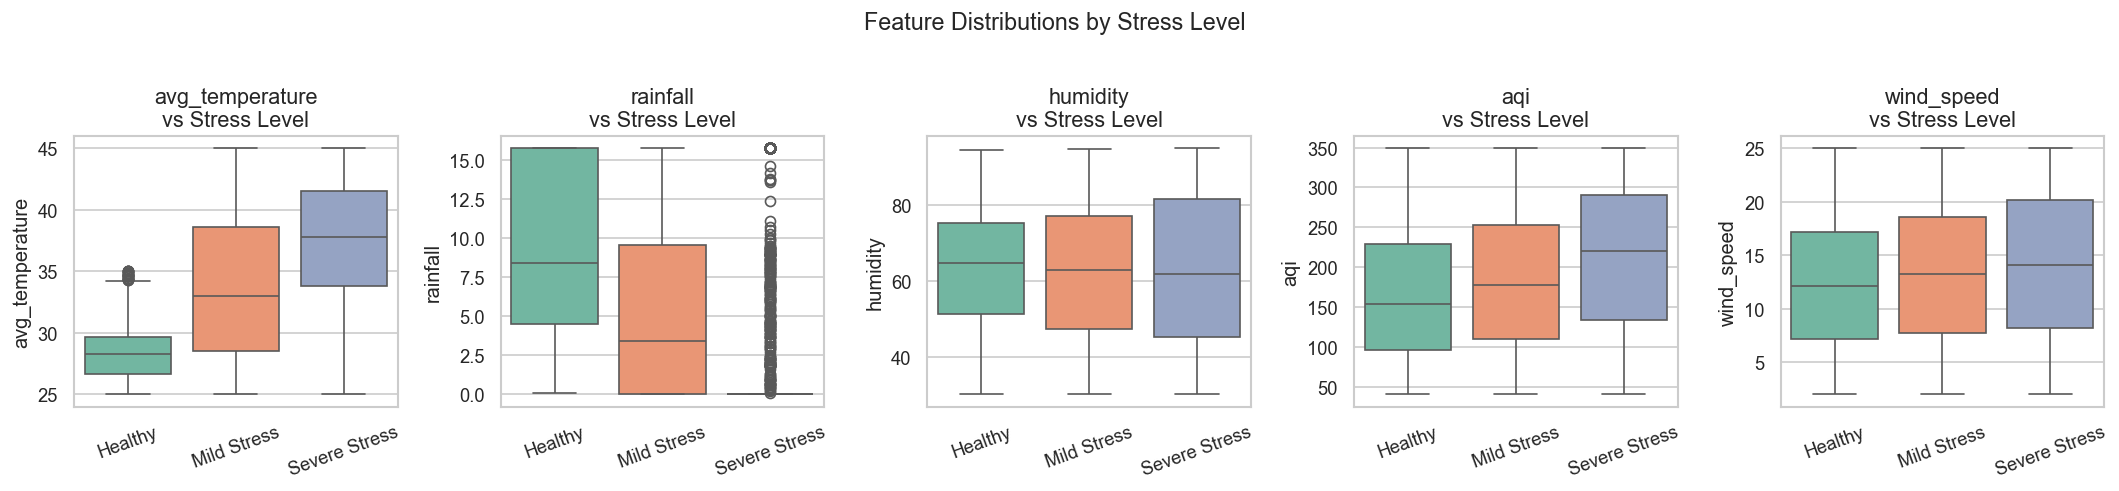

In [34]:
plot_cols = ["avg_temperature", "rainfall", "humidity", "aqi", "wind_speed"]
fig, axes = plt.subplots(1, len(plot_cols), figsize=(18, 4))

for ax, col in zip(axes, plot_cols):
    sns.boxplot(
        data=df, x="stress_level", y=col,
        order=order_stress, palette="Set2", ax=ax
    )
    ax.set_title(f"{col}\nvs Stress Level")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)

plt.suptitle("Feature Distributions by Stress Level", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/03_boxplots_stress.png")
plt.show()

### 11.3 Feature Correlation Heatmap

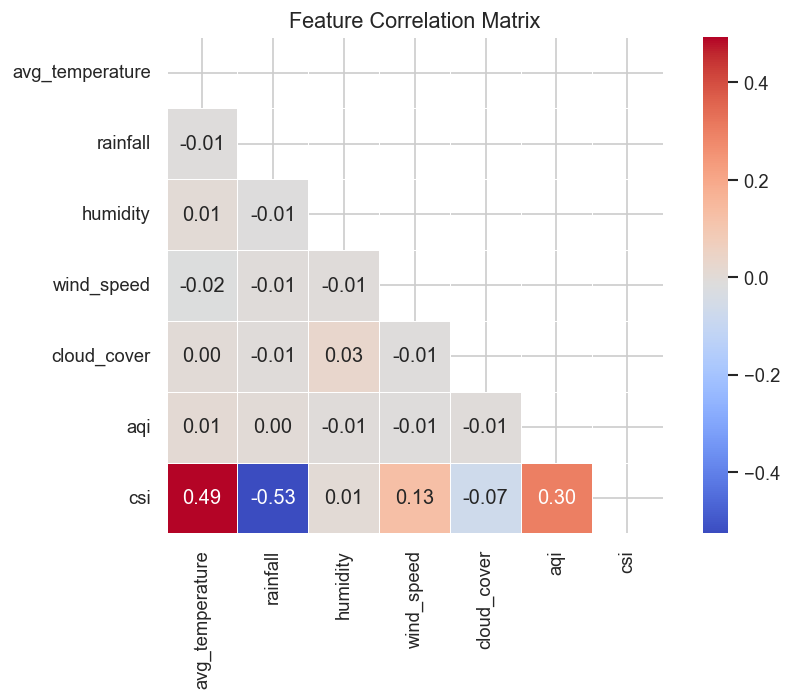

In [35]:
corr_cols = NUM_COLS + ["csi"]
corr_cols = [c for c in corr_cols if c in df.columns]
corr = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle mask
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            mask=mask, linewidths=0.5, square=True)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/04_correlation_heatmap.png")
plt.show()

### 11.4 Monthly Climate Trends

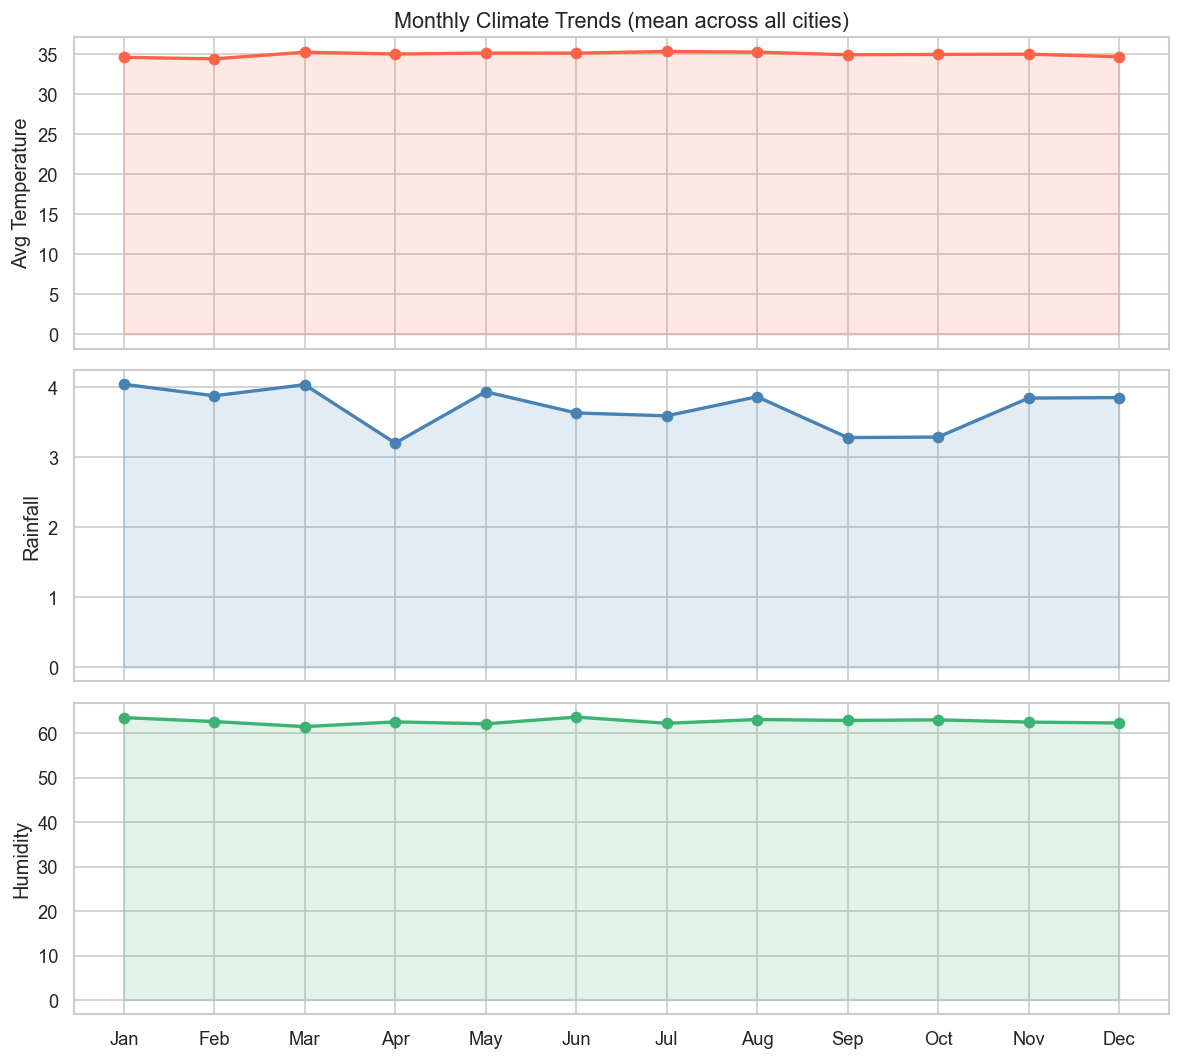

In [36]:
monthly = df.groupby("month")[["avg_temperature", "rainfall", "humidity"]].mean()

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

for ax, col, color in zip(
    axes,
    ["avg_temperature", "rainfall", "humidity"],
    ["tomato", "steelblue", "mediumseagreen"]
):
    ax.plot(monthly.index, monthly[col], marker="o", color=color, linewidth=2)
    ax.fill_between(monthly.index, monthly[col], alpha=0.15, color=color)
    ax.set_ylabel(col.replace("_", " ").title())
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels)

axes[0].set_title("Monthly Climate Trends (mean across all cities)")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/05_monthly_trends.png")
plt.show()

### 11.5 CSI Distribution by Season

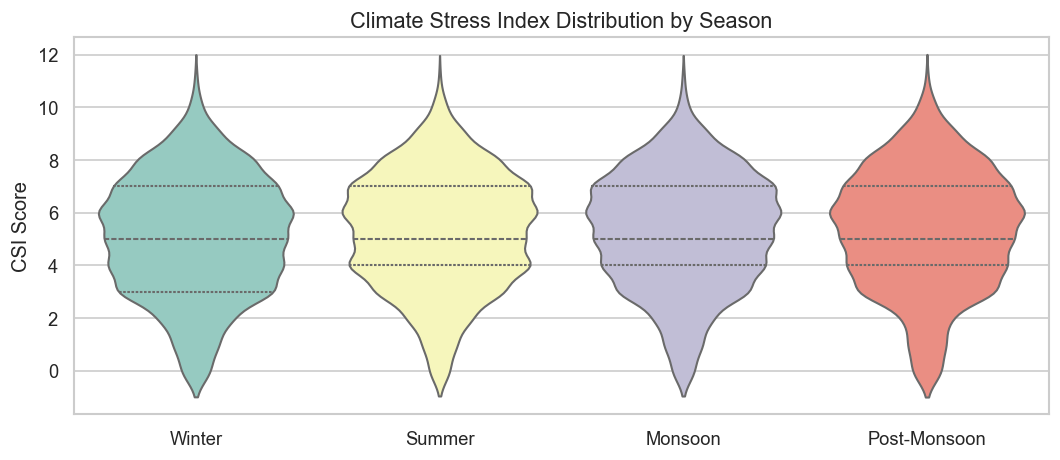


All EDA figures saved to: C:\Users\nilad\CSS_hackathon-Tea-Climate-Analyzer\Figures


In [37]:
if "season" in df.columns:
    fig, ax = plt.subplots(figsize=(9, 4))
    sns.violinplot(
        data=df, x="season", y="csi",
        order=["Winter", "Summer", "Monsoon", "Post-Monsoon"],
        palette="Set3", inner="quartile", ax=ax
    )
    ax.set_title("Climate Stress Index Distribution by Season")
    ax.set_xlabel("")
    ax.set_ylabel("CSI Score")
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/06_csi_by_season.png")
    plt.show()

    print("\nAll EDA figures saved to:", FIGURES_DIR)